# Three-Gate SQR Duration Optimization

This notebook reuses the same 3 SQR gates from
`decomposition/cluster_U_T_1-1e+03ns-3_sqr-no_phases` and evaluates them with the
shared multitone-Gaussian SQR workflow in `cqed_sim`.

What this notebook does:
- loads the same three extracted SQR targets,
- audits the execution path used by the notebook,
- sweeps SQR duration on a fixed grid,
- reports the minimum scanned duration that reaches a chosen fidelity threshold,
- compares the nominal pulse (no optimization corrections) against the optimized pulse,
- supports optional T1/T2 dissipation through the shared simulator path,
- supports optional process-based parallel execution across independent multistart candidates,
- prints the optimized tone corrections used by the best solution for each gate,
- writes a concise markdown report into the configured output directory.

The fidelity threshold and sweep grid are user-configurable below. The reported minimum
is the minimum **on the scanned grid**, not a continuous-time optimum.

In [1]:
from __future__ import annotations

from dataclasses import asdict
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from cqed_sim.analysis import SQRSpeedLimitConfig, TargetCase, evaluate_nominal_case, run_speedlimit_sweep_point
from cqed_sim.calibration.sqr import RandomSQRTarget
from cqed_sim.io.gates import SQRGate, load_gate_sequence, render_gate_table

np.set_printoptions(precision=6, suppress=True)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 120

## User Configuration

In [2]:
SEED = 1234
DECOMPOSITION_PATH = r"decomposition\cluster_U_T_1-1e+03ns-3_sqr-no_phases"

# The threshold is intentionally user-editable. The notebook reports the minimum
# duration on the scanned grid that reaches this subspace fidelity.
FIDELITY_THRESHOLD = 0.98
DURATIONS_NS = np.linspace(500, 1000, 11)
SIGMA_FRACTIONS = (0.16,)

# This mirrors the low-lying matched subspace used for the three-gate study.
N_MATCH = 3
GUARD_LEVELS = 1
CHI_HZ = -2.84e6
CHI2_HZ = -21e3
KERR_HZ = 0.0
KERR2_HZ = 0.0
OMEGA_Q_HZ = 0.0
OMEGA_C_HZ = 0.0
QUBIT_ALPHA_HZ = 0.0
USE_ROTATING_FRAME = True

# Optional dissipation. Leave these as None to recover coherent/unitary evaluation.
QB_T1_RELAX_NS = None
QB_T2_RAMSEY_NS = None
QB_T2_ECHO_NS = None
T2_SOURCE = "ramsey"
CAVITY_KAPPA_1_PER_S = 0.0

# Runtime-balanced defaults. Increase these if you want a tighter search.
MULTISTART = 1
PARALLEL_ENABLED = False
PARALLEL_N_JOBS = 2
OPTIMIZER_MAXITER_STAGE1 = 3
OPTIMIZER_MAXITER_STAGE2 = 4
DT_S = 1.0e-9
MAX_STEP_S = 2.0e-9
QUTIP_NSTEPS = 100000

d_omega_bounds = (-1e6, 1e6)
OUTPUT_ROOT = Path("outputs/sqr_three_gate_optimization")
REPORT_PATH = OUTPUT_ROOT / f"seed_{SEED}" / "three_gate_speedlimit_report.md"

## Load the Same Three SQR Gates

In [3]:
seq_path, gates = load_gate_sequence(DECOMPOSITION_PATH)
sqr_gates = [gate for gate in gates if isinstance(gate, SQRGate)]

print(f"Loaded sequence: {seq_path}")
print(f"Total gates: {len(gates)}")
print(f"SQR gates found: {len(sqr_gates)}")
render_gate_table(sqr_gates, max_rows=10)

assert len(sqr_gates) == 3, "Expected exactly three SQR gates in the decomposition file."

for gate in sqr_gates:
    theta = np.asarray(gate.theta, dtype=float)
    phi = np.asarray(gate.phi, dtype=float)
    active = np.where(np.abs(theta) > 1.0e-10)[0].tolist()
    print(f"\n{gate.name}")
    print("  theta[:6] =", theta[:6])
    print("  phi[:6]   =", phi[:6])
    print("  active target levels =", active)


Loaded sequence: decomposition\cluster_U_T_1-1e+03ns-3_sqr-no_phases
Total gates: 10
SQR gates found: 3
  #  Type         Target   Name                                     Params
--------------------------------------------------------------------------
  2  SQR          qubit    SQR_527e17733de113ecaead4876b2bcafeb     tones=12, active=1
  5  SQR          qubit    SQR_bc8194a85a260be4c0959c6c4d8d7ae1     tones=12, active=1
  8  SQR          qubit    SQR_789278ba62949511b06e9d76a4bb8437     tones=12, active=1

SQR_527e17733de113ecaead4876b2bcafeb
  theta[:6] = [5.637238 0.       0.       0.       0.       0.      ]
  phi[:6]   = [1.545128 0.       0.       0.       0.       0.      ]
  active target levels = [0]

SQR_bc8194a85a260be4c0959c6c4d8d7ae1
  theta[:6] = [-4.121375  0.        0.        0.        0.        0.      ]
  phi[:6]   = [1.562768 0.       0.       0.       0.       0.      ]
  active target levels = [0]

SQR_789278ba62949511b06e9d76a4bb8437
  theta[:6] = [-4.603699  0

In [4]:
execution_audit_df = pd.DataFrame(
    [
        {
            "stage": "Notebook entry",
            "callable": "cqed_sim.analysis.run_speedlimit_sweep_point",
            "role": "Sweep orchestration over sigma and multistart candidates",
        },
        {
            "stage": "Nominal comparison",
            "callable": "cqed_sim.analysis.evaluate_nominal_case",
            "role": "Nominal waveform and fidelity evaluation at the selected duration",
        },
        {
            "stage": "Waveform generation",
            "callable": "cqed_sim.pulses.calibration.build_sqr_tone_specs",
            "role": "Canonical multitone Gaussian tone construction",
        },
        {
            "stage": "Hamiltonian assembly",
            "callable": "cqed_sim.sim.runner.hamiltonian_time_slices",
            "role": "Shared model/frame drive Hamiltonian construction",
        },
        {
            "stage": "Propagation",
            "callable": "qutip.propagator / qutip.mesolve",
            "role": "Unitary propagation when dissipation is disabled, Lindblad evolution when T1/T2 are set",
        },
        {
            "stage": "Objective",
            "callable": "cqed_sim.calibration.evaluate_guarded_sqr_target",
            "role": "Logical process fidelity plus guarded selectivity penalty",
        },
    ]
)
display(execution_audit_df)

print("Original pre-refactor execution path:")
print("  notebook -> cqed_sim.analysis.sqr_speedlimit_multitone_gaussian")
print("  -> cqed_sim.calibration.sqr.extract_multitone_effective_qubit_unitary / calibrate_guarded_sqr_target")
print("  -> custom reduced two-level QuTiP propagation per manifold")

print("\nCurrent shared-stack execution path:")
print("  notebook -> cqed_sim.analysis.sqr_speedlimit_multitone_gaussian")
print("  -> cqed_sim.calibration.sqr")
print("  -> cqed_sim.pulses.calibration.build_sqr_tone_specs")
print("  -> cqed_sim.sim.runner.hamiltonian_time_slices")
print("  -> qutip.propagator (coherent) or qutip.mesolve (dissipative)")

,stage,callable,role
0,Notebook entry,cqed_sim.analysis.run_speedlimit_sweep_point,Sweep orchestration over sigma and multistart ...
1,Nominal comparison,cqed_sim.analysis.evaluate_nominal_case,Nominal waveform and fidelity evaluation at th...
2,Waveform generation,cqed_sim.pulses.calibration.build_sqr_tone_specs,Canonical multitone Gaussian tone construction
3,Hamiltonian assembly,cqed_sim.sim.runner.hamiltonian_time_slices,Shared model/frame drive Hamiltonian construction
4,Propagation,qutip.propagator / qutip.mesolve,Unitary propagation when dissipation is disabl...
5,Objective,cqed_sim.calibration.evaluate_guarded_sqr_target,Logical process fidelity plus guarded selectiv...


Original pre-refactor execution path:
  notebook -> cqed_sim.analysis.sqr_speedlimit_multitone_gaussian
  -> cqed_sim.calibration.sqr.extract_multitone_effective_qubit_unitary / calibrate_guarded_sqr_target
  -> custom reduced two-level QuTiP propagation per manifold

Current shared-stack execution path:
  notebook -> cqed_sim.analysis.sqr_speedlimit_multitone_gaussian
  -> cqed_sim.calibration.sqr
  -> cqed_sim.pulses.calibration.build_sqr_tone_specs
  -> cqed_sim.sim.runner.hamiltonian_time_slices
  -> qutip.propagator (coherent) or qutip.mesolve (dissipative)


## Execution Path Audit

## Build Study Configuration and Helpers

In [5]:


def _as_int_tuple(values):
    if isinstance(values, (int, np.integer)):
        return (int(values),)
    return tuple(int(x) for x in values)

def _as_float_tuple(values):
    if isinstance(values, (int, float, np.integer, np.floating)):
        return (float(values),)
    return tuple(float(x) for x in values)

study = SQRSpeedLimitConfig(
    seed=SEED,
    n_match=N_MATCH,
    guard_levels=GUARD_LEVELS,
    chi_hz=CHI_HZ,
    chi2_hz=CHI2_HZ,
    kerr_hz=KERR_HZ,
    kerr2_hz=KERR2_HZ,
    omega_q_hz=OMEGA_Q_HZ,
    omega_c_hz=OMEGA_C_HZ,
    qubit_alpha_hz=QUBIT_ALPHA_HZ,
    use_rotating_frame=USE_ROTATING_FRAME,
    qb_t1_relax_ns=QB_T1_RELAX_NS,
    qb_t2_ramsey_ns=QB_T2_RAMSEY_NS,
    qb_t2_echo_ns=QB_T2_ECHO_NS,
    t2_source=T2_SOURCE,
    cavity_kappa_1_per_s=CAVITY_KAPPA_1_PER_S,
    durations_ns=_as_int_tuple(DURATIONS_NS),
    sigma_fractions=_as_float_tuple(SIGMA_FRACTIONS),
    multistart=int(MULTISTART),
    parallel_enabled=bool(PARALLEL_ENABLED),
    parallel_n_jobs=int(PARALLEL_N_JOBS),
    dt_s=float(DT_S),
    max_step_s=float(MAX_STEP_S),
    optimizer_maxiter_stage1=int(OPTIMIZER_MAXITER_STAGE1),
    optimizer_maxiter_stage2=int(OPTIMIZER_MAXITER_STAGE2),
    qutip_nsteps_sqr_calibration=int(QUTIP_NSTEPS),
    output_root=OUTPUT_ROOT,
    report_path=REPORT_PATH,
    d_omega_hz_bounds=(d_omega_bounds)
 )
output_dir = study.output_dir()
output_dir.mkdir(parents=True, exist_ok=True)
print("Output directory:", output_dir)
print("Study config:")
print(json.dumps(asdict(study), indent=2, default=str))
print("Dissipation enabled:", any(value not in (None, 0, 0.0) for value in (study.qb_t1_relax_ns, study.qb_t2_ramsey_ns, study.qb_t2_echo_ns, study.cavity_kappa_1_per_s)))
print("Parallel candidate evaluation enabled:", study.parallel_enabled, "| n_jobs =", study.parallel_n_jobs)


def make_case_from_gate(gate: SQRGate, gate_index: int, study_cfg: SQRSpeedLimitConfig) -> TargetCase:
    theta = tuple(float(x) for x in gate.theta[: study_cfg.logical_n]) + tuple(0.0 for _ in range(study_cfg.guard_levels))
    phi = tuple(float(x) for x in gate.phi[: study_cfg.logical_n]) + tuple(0.0 for _ in range(study_cfg.guard_levels))
    return TargetCase(
        name=f"gate_{gate_index:02d}",
        description=gate.name,
        target=RandomSQRTarget(
            target_id=gate.name,
            target_class="three_gate",
            logical_n=int(study_cfg.logical_n),
            guard_levels=int(study_cfg.guard_levels),
            theta=theta,
            phi=phi,
        ),
        phase="three_gate",
        composite_with_ideal_pi=False,
    )


def point_to_row(point: dict) -> dict:
    return {
        "duration_ns": float(point["duration_ns"]),
        "sigma_fraction": float(point["sigma_fraction"]),
        "subspace_fidelity": float(point["subspace_fidelity"]),
        "guard_selectivity_error": float(point["guard_selectivity_error"]),
        "logical_fidelity_weighted": float(point["logical_fidelity_weighted"]),
        "objective_loss_total": float(point["objective_loss_total"]),
        "selected_run_id": str(point["selected_run_id"]),
        "simulation_mode": str(point.get("simulation_mode", "unitary")),
        "parallel_used": bool(point.get("parallel_used", False)),
    }


def minimum_duration_row(rows: list[dict], threshold: float) -> dict | None:
    ordered = sorted(rows, key=lambda row: float(row["duration_ns"]))
    for row in ordered:
        if float(row["subspace_fidelity"]) >= float(threshold):
            return row
    return None


def calibration_table(point: dict) -> pd.DataFrame:
    rows = list(point["calibration_summary"].get("levels", []))
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    keep = [
        "n",
        "theta_target",
        "phi_target",
        "optimized_params",
        "process_fidelity",
        "initial_loss",
        "optimized_loss",
        "skipped",
    ]
    return df[keep]


def tone_table(waveform: dict) -> pd.DataFrame:
    tones = list(waveform.get("tones", []))
    if not tones:
        return pd.DataFrame(columns=["n", "amp_rad_s", "phase_rad", "omega_hz"])

    df = pd.DataFrame(tones).sort_values("n").reset_index(drop=True)
    df["amp_Mrad_s"] = df["amp_rad_s"] / 1.0e6
    df["omega_MHz"] = df["omega_hz"] / 1.0e6
    return df[["n", "amp_rad_s", "amp_Mrad_s", "phase_rad", "omega_hz", "omega_MHz"]]


def tone_comparison_table(nominal_waveform: dict, optimized_waveform: dict) -> pd.DataFrame:
    nominal = tone_table(nominal_waveform).rename(columns={
        "amp_rad_s": "amp_rad_s_nominal",
        "amp_Mrad_s": "amp_Mrad_s_nominal",
        "phase_rad": "phase_rad_nominal",
        "omega_hz": "omega_hz_nominal",
        "omega_MHz": "omega_MHz_nominal",
    })
    optimized = tone_table(optimized_waveform).rename(columns={
        "amp_rad_s": "amp_rad_s_optimized",
        "amp_Mrad_s": "amp_Mrad_s_optimized",
        "phase_rad": "phase_rad_optimized",
        "omega_hz": "omega_hz_optimized",
        "omega_MHz": "omega_MHz_optimized",
    })
    merged = nominal.merge(optimized, on="n", how="outer").sort_values("n").reset_index(drop=True)
    return merged


def plot_fidelity_sweeps(results: list[dict], threshold: float) -> None:
    fig, axes = plt.subplots(1, len(results), figsize=(5.0 * len(results), 4.0), sharey=True)
    if len(results) == 1:
        axes = [axes]
    for ax, result in zip(axes, results, strict=False):
        rows = sorted(result["sweep_rows"], key=lambda row: row["duration_ns"])
        durations = np.asarray([row["duration_ns"] for row in rows], dtype=float)
        fidelity = np.asarray([row["subspace_fidelity"] for row in rows], dtype=float)
        ax.plot(durations, fidelity, "o-", color="tab:blue", label="optimized")
        ax.axhline(float(threshold), color="tab:red", linestyle="--", linewidth=1.0, label="threshold")
        if result["threshold_row"] is not None:
            ax.axvline(float(result["threshold_row"]["duration_ns"]), color="0.5", linestyle=":", linewidth=1.0)
        ax.set_title(result["gate"].name)
        ax.set_xlabel("T_SQR [ns]")
        ax.set_ylabel("Subspace fidelity")
        ax.set_ylim(0.0, 1.01)
        ax.grid(alpha=0.25)
    axes[0].legend()
    fig.tight_layout()
    plt.show()


def plot_waveform_overlay(nominal_waveform: dict, optimized_waveform: dict, title: str) -> None:
    t_ns = np.asarray(optimized_waveform["tlist_s"], dtype=float) * 1.0e9
    fig, axes = plt.subplots(3, 1, figsize=(10.0, 7.0), sharex=True)
    axes[0].plot(t_ns, np.asarray(nominal_waveform["i"], dtype=float), color="0.6", linewidth=1.5, label="nominal")
    axes[0].plot(t_ns, np.asarray(optimized_waveform["i"], dtype=float), color="tab:blue", linewidth=1.5, label="optimized")
    axes[0].set_ylabel("I(t) [rad/s]")
    axes[1].plot(t_ns, np.asarray(nominal_waveform["q"], dtype=float), color="0.6", linewidth=1.5, label="nominal")
    axes[1].plot(t_ns, np.asarray(optimized_waveform["q"], dtype=float), color="tab:orange", linewidth=1.5, label="optimized")
    axes[1].set_ylabel("Q(t) [rad/s]")
    axes[2].plot(t_ns, np.asarray(nominal_waveform["magnitude"], dtype=float), color="0.6", linewidth=1.5, label="nominal")
    axes[2].plot(t_ns, np.asarray(optimized_waveform["magnitude"], dtype=float), color="tab:green", linewidth=1.5, label="optimized")
    axes[2].set_ylabel("|Omega(t)|")
    axes[2].set_xlabel("Time [ns]")
    for ax in axes:
        ax.grid(alpha=0.25)
    axes[0].legend(loc="upper right")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def plot_spectrum_overlay(nominal_waveform: dict, optimized_waveform: dict, title: str) -> None:
    coeff_nom = np.asarray(nominal_waveform["coeff"], dtype=np.complex128)
    coeff_opt = np.asarray(optimized_waveform["coeff"], dtype=np.complex128)
    tlist = np.asarray(optimized_waveform["tlist_s"], dtype=float)
    if coeff_opt.size < 2:
        return
    dt = float(tlist[1] - tlist[0])
    freq_hz = np.fft.fftshift(np.fft.fftfreq(coeff_opt.size, d=dt)) / 1.0e6
    spec_nom = np.fft.fftshift(np.fft.fft(coeff_nom))
    spec_opt = np.fft.fftshift(np.fft.fft(coeff_opt))
    scale = max(float(np.max(np.abs(spec_nom))), float(np.max(np.abs(spec_opt))), 1.0e-18)
    fig, ax = plt.subplots(figsize=(10.0, 4.0))
    ax.plot(freq_hz, 20.0 * np.log10(np.abs(spec_nom) / scale + 1.0e-15), color="0.6", linewidth=1.4, label="nominal")
    ax.plot(freq_hz, 20.0 * np.log10(np.abs(spec_opt) / scale + 1.0e-15), color="tab:purple", linewidth=1.4, label="optimized")
    for tone in optimized_waveform.get("tones", []):
        ax.axvline(float(tone["omega_hz"]) / 1.0e6, color="0.5", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel("Normalized spectrum [dB]")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    plt.show()


def plot_selected_history(point: dict, title: str) -> None:
    history = list(point.get("history", []))
    if not history:
        print("No recorded history for", title)
        return
    df = pd.json_normalize(history)
    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.0))
    axes[0].plot(df["iteration"], df["objective_total"], color="tab:blue")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Objective")
    axes[0].grid(alpha=0.25)
    if "metrics.fidelity_subspace" in df.columns:
        axes[1].plot(df["iteration"], df["metrics.fidelity_subspace"], color="tab:green")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Subspace fidelity")
    axes[1].grid(alpha=0.25)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

Output directory: outputs\sqr_three_gate_optimization\seed_1234
Study config:
{
  "seed": 1234,
  "n_match": 3,
  "guard_levels": 1,
  "chi_hz": -2840000.0,
  "chi2_hz": -21000.0,
  "chi3_hz": 0.0,
  "kerr_hz": 0.0,
  "kerr2_hz": 0.0,
  "omega_q_hz": 0.0,
  "omega_c_hz": 0.0,
  "qubit_alpha_hz": 0.0,
  "use_rotating_frame": true,
  "qb_t1_relax_ns": null,
  "qb_t2_ramsey_ns": null,
  "qb_t2_echo_ns": null,
  "t2_source": "ramsey",
  "cavity_kappa_1_per_s": 0.0,
  "durations_ns": [
    500,
    550,
    600,
    650,
    700,
    750,
    800,
    850,
    900,
    950,
    1000
  ],
  "sigma_fractions": [
    0.16
  ],
  "multistart": 1,
  "parallel_enabled": false,
  "parallel_n_jobs": 2,
  "dt_s": 1e-09,
  "max_step_s": 2e-09,
  "optimizer_maxiter_stage1": 3,
  "optimizer_maxiter_stage2": 4,
  "d_lambda_bounds": [
    -0.5,
    0.5
  ],
  "d_alpha_bounds": [
    -3.141592653589793,
    3.141592653589793
  ],
  "d_omega_hz_bounds": [
    -1000000.0,
    1000000.0
  ],
  "lambda_guard"

## Run the Duration Sweep

In [ ]:
gate_results = []

for gate_index, gate in enumerate(sqr_gates, start=1):
    case = make_case_from_gate(gate, gate_index, study)
    case_dir = output_dir / f"gate_{gate_index:02d}_{case.name}"
    case_dir.mkdir(parents=True, exist_ok=True)

    sweep_rows = []
    point_payloads = {}
    print(f"\n=== Gate {gate_index}: {gate.name} ===")
    for duration_ns in study.durations_ns:
        point = run_speedlimit_sweep_point(
            case=case,
            duration_s=float(duration_ns) * 1.0e-9,
            study=study,
            point_output_dir=case_dir / f"T_{int(duration_ns):04d}ns",
        )
        point_payloads[int(duration_ns)] = point
        row = point_to_row(point)
        sweep_rows.append(row)
        print(
            f"  T={int(duration_ns):4d} ns | F={row['subspace_fidelity']:.6f} | "
            f"sigma={row['sigma_fraction']:.2f} | guard={row['guard_selectivity_error']:.3e} | "
            f"mode={row['simulation_mode']} | parallel={row['parallel_used']}"
        )

    threshold_row = minimum_duration_row(sweep_rows, FIDELITY_THRESHOLD)
    if threshold_row is not None:
        selected_duration_ns = int(round(float(threshold_row["duration_ns"])))
        selection_reason = f"first duration reaching F >= {FIDELITY_THRESHOLD:.3f}"
    else:
        best_row = max(sweep_rows, key=lambda row: float(row["subspace_fidelity"]))
        selected_duration_ns = int(round(float(best_row["duration_ns"])))
        selection_reason = "threshold not reached on grid; using best scanned duration"

    selected_point = point_payloads[selected_duration_ns]
    nominal = evaluate_nominal_case(
        case=case,
        study=study,
        duration_s=float(selected_duration_ns) * 1.0e-9,
        sigma_fraction=float(selected_point["sigma_fraction"]),
    )
    gate_results.append(
        {
            "gate_index": int(gate_index),
            "gate": gate,
            "case": case,
            "case_dir": case_dir,
            "sweep_rows": sweep_rows,
            "point_payloads": point_payloads,
            "threshold_row": threshold_row,
            "selected_duration_ns": int(selected_duration_ns),
            "selected_point": selected_point,
            "nominal": nominal,
            "selection_reason": selection_reason,
        }
    )

summary_payload = {
    "seed": int(SEED),
    "fidelity_threshold": float(FIDELITY_THRESHOLD),
    "durations_ns": [int(x) for x in study.durations_ns],
    "sigma_fractions": [float(x) for x in study.sigma_fractions],
    "dissipation_enabled": any(value not in (None, 0, 0.0) for value in (study.qb_t1_relax_ns, study.qb_t2_ramsey_ns, study.qb_t2_echo_ns, study.cavity_kappa_1_per_s)),
    "parallel_enabled": bool(study.parallel_enabled),
    "parallel_n_jobs": int(study.parallel_n_jobs),
    "results": [
        {
            "gate_index": int(result["gate_index"]),
            "gate_name": result["gate"].name,
            "selected_duration_ns": int(result["selected_duration_ns"]),
            "selected_sigma_fraction": float(result["selected_point"]["sigma_fraction"]),
            "selected_fidelity": float(result["selected_point"]["subspace_fidelity"]),
            "baseline_fidelity": float(result["nominal"]["subspace_fidelity"]),
            "selection_reason": result["selection_reason"],
            "simulation_mode": str(result["selected_point"].get("simulation_mode", "unitary")),
            "execution_path": str(result["selected_point"].get("execution_path", "")),
            "parallel_used": bool(result["selected_point"].get("parallel_used", False)),
            "threshold_row": None if result["threshold_row"] is None else dict(result["threshold_row"]),
            "sweep_rows": list(result["sweep_rows"]),
        }
        for result in gate_results
    ],
}
summary_path = output_dir / "three_gate_summary.json"
summary_path.write_text(json.dumps(summary_payload, indent=2), encoding="utf-8")
print("\nWrote summary:", summary_path)


=== Gate 1: SQR_527e17733de113ecaead4876b2bcafeb ===
  T= 500 ns | F=0.238511 | sigma=0.16 | guard=1.980e-07 | mode=unitary | parallel=False
  T= 550 ns | F=0.836554 | sigma=0.16 | guard=2.785e-06 | mode=unitary | parallel=False
  T= 600 ns | F=0.530857 | sigma=0.16 | guard=3.430e-05 | mode=unitary | parallel=False
  T= 650 ns | F=0.873946 | sigma=0.16 | guard=1.271e-04 | mode=unitary | parallel=False
  T= 700 ns | F=0.871830 | sigma=0.16 | guard=2.391e-05 | mode=unitary | parallel=False


## Minimum Duration Summary

In [ ]:
summary_rows = []
for result in gate_results:
    best_row = max(result["sweep_rows"], key=lambda row: float(row["subspace_fidelity"]))
    summary_rows.append(
        {
            "gate_index": int(result["gate_index"]),
            "gate_name": result["gate"].name,
            "target_theta_n0_rad": float(result["case"].target.theta[0]),
            "target_phi_n0_rad": float(result["case"].target.phi[0]),
            "min_duration_ns": None if result["threshold_row"] is None else float(result["threshold_row"]["duration_ns"]),
            "selected_duration_ns": float(result["selected_duration_ns"]),
            "selected_sigma_fraction": float(result["selected_point"]["sigma_fraction"]),
            "selected_fidelity": float(result["selected_point"]["subspace_fidelity"]),
            "baseline_fidelity_same_duration": float(result["nominal"]["subspace_fidelity"]),
            "fidelity_gain": float(result["selected_point"]["subspace_fidelity"] - result["nominal"]["subspace_fidelity"]),
            "best_scanned_duration_ns": float(best_row["duration_ns"]),
            "best_scanned_fidelity": float(best_row["subspace_fidelity"]),
            "simulation_mode": str(result["selected_point"].get("simulation_mode", "unitary")),
            "parallel_used": bool(result["selected_point"].get("parallel_used", False)),
            "selection_reason": result["selection_reason"],
        }
    )
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

if summary_df["min_duration_ns"].notna().all():
    common_min_duration_ns = float(summary_df["min_duration_ns"].max())
    print(f"Common minimum scanned duration reaching F >= {FIDELITY_THRESHOLD:.3f} for all three gates: {common_min_duration_ns:.1f} ns")
else:
    print(f"At least one gate did not reach F >= {FIDELITY_THRESHOLD:.3f} on the scanned grid.")
    print("Use the selected_duration_ns column for the per-gate operating point chosen for waveform comparison.")

,gate_index,gate_name,target_theta_n0_rad,target_phi_n0_rad,min_duration_ns,selected_duration_ns,selected_sigma_fraction,selected_fidelity,baseline_fidelity_same_duration,fidelity_gain,best_scanned_duration_ns,best_scanned_fidelity,selection_reason
0,1,SQR_527e17733de113ecaead4876b2bcafeb,5.637238,1.545128,None,1000.0,0.16,0.921466,0.905310,0.016156,1000.0,0.921466,threshold not reached on grid; using best scan...
1,2,SQR_bc8194a85a260be4c0959c6c4d8d7ae1,-4.121375,1.562768,None,650.0,0.16,0.951451,0.928767,0.022685,650.0,0.951451,threshold not reached on grid; using best scan...
2,3,SQR_789278ba62949511b06e9d76a4bb8437,-4.603699,1.578716,None,750.0,0.16,0.941427,0.921908,0.019518,750.0,0.941427,threshold not reached on grid; using best scan...


At least one gate did not reach F >= 0.980 on the scanned grid.
Use the selected_duration_ns column for the per-gate operating point chosen for waveform comparison.


## Optimized Fidelity Sweep

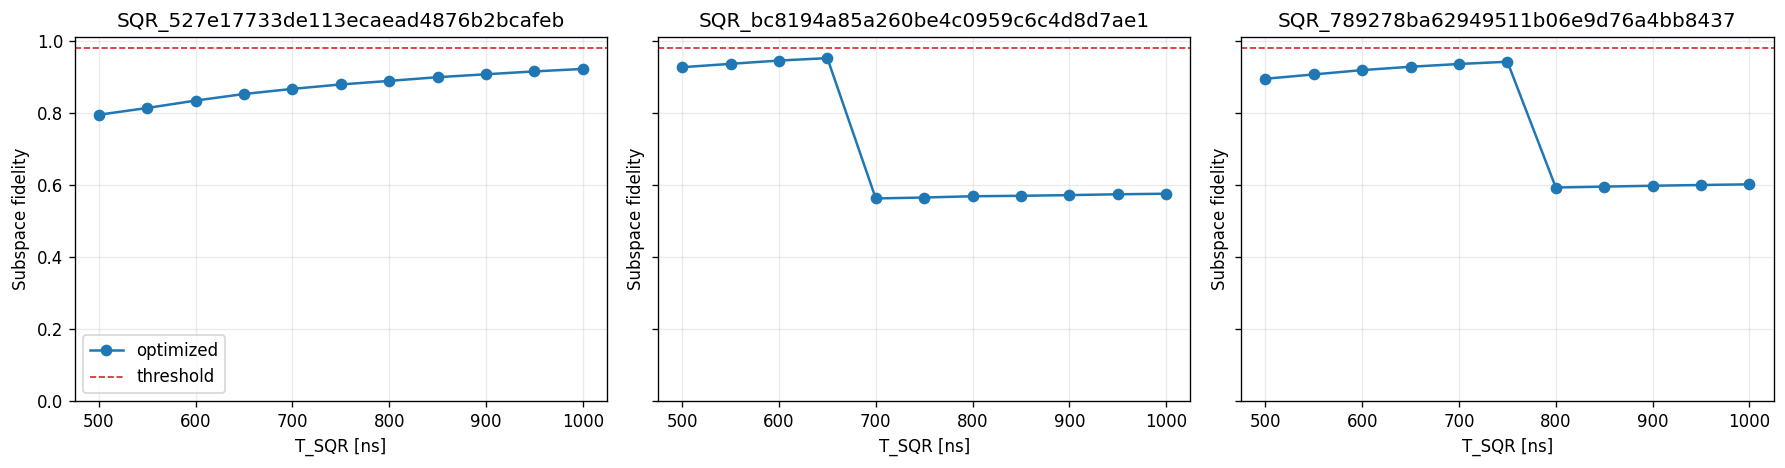

In [ ]:
plot_fidelity_sweeps(gate_results, FIDELITY_THRESHOLD)

## Optimized Parameters Per Gate

In [ ]:
for result in gate_results:
    display(Markdown(f"### Gate {result['gate_index']}: `{result['gate'].name}`"))
    print("Selection reason:", result["selection_reason"])
    print(
        "Selected point: "
        f"T={result['selected_duration_ns']} ns, "
        f"sigma={result['selected_point']['sigma_fraction']:.2f}, "
        f"F={result['selected_point']['subspace_fidelity']:.6f}, "
        f"guard={result['selected_point']['guard_selectivity_error']:.3e}"
    )
    display(calibration_table(result["selected_point"]))

### Gate 1: `SQR_527e17733de113ecaead4876b2bcafeb`

Selection reason: threshold not reached on grid; using best scanned duration
Selected point: T=1000 ns, sigma=0.16, F=0.921466, guard=2.426e-03


,n,theta_target,phi_target,optimized_params,process_fidelity,initial_loss,optimized_loss,skipped
0,0,5.637238,1.545128,"(-0.5, -0.08362717383691146, 213317.85389642592)",0.968561,0.000000,0.031439,False
1,1,0.000000,0.000000,"(0.2050422188359669, 0.021075782310372645, 299...",0.615338,0.470116,0.384662,False
2,2,0.000000,0.000000,"(0.026394775985686084, 0.3815863439191337, 875...",0.888919,0.142045,0.111081,False
3,3,0.000000,0.000000,"(0.024198184720726483, 0.2315759004881308, 497...",0.949552,0.064815,0.050448,False
4,4,0.000000,0.000000,"(0.0, 0.0, 0.0)",0.971668,0.036455,0.028332,True


### Gate 2: `SQR_bc8194a85a260be4c0959c6c4d8d7ae1`

Selection reason: threshold not reached on grid; using best scanned duration
Selected point: T=650 ns, sigma=0.16, F=0.951451, guard=1.346e-06


,n,theta_target,phi_target,optimized_params,process_fidelity,initial_loss,optimized_loss,skipped
0,0,-4.121375,1.562768,"(0.5, -0.06333058923345321, 222674.8697689968)",0.955295,0.000000,0.044705,False
1,1,0.000000,0.000000,"(0.5, 0.9359803220028176, 716215.0579039966)",0.764594,0.377228,0.235406,False
2,2,0.000000,0.000000,"(-0.017104448941295772, 1.413128612559052, -10...",0.937194,0.100358,0.062806,False
3,3,0.000000,0.000000,"(-0.03482894884993729, 0.4306678446611617, -18...",0.972029,0.044665,0.027971,False
4,4,0.000000,0.000000,"(0.0, 0.0, 0.0)",0.984418,0.024912,0.015582,True


### Gate 3: `SQR_789278ba62949511b06e9d76a4bb8437`

Selection reason: threshold not reached on grid; using best scanned duration
Selected point: T=750 ns, sigma=0.16, F=0.941427, guard=9.363e-05


,n,theta_target,phi_target,optimized_params,process_fidelity,initial_loss,optimized_loss,skipped
0,0,-4.603699,1.578716,"(0.5, -0.032812353008868235, 152110.80758108586)",0.959980,0.000002,0.040020,False
1,1,0.000000,0.000000,"(-0.5, -1.529283727579739, 1471414.213810622)",0.711673,0.402280,0.288327,False
2,2,0.000000,0.000000,"(0.05740123594059108, -0.6028458570542736, 146...",0.921856,0.114990,0.078144,False
3,3,0.000000,0.000000,"(-0.06653890704666172, -0.029996720452989564, ...",0.964677,0.051790,0.035323,False
4,4,0.000000,0.000000,"(0.0, 0.0, 0.0)",0.980395,0.028995,0.019605,True


## Unoptimized Pulse vs Optimized Pulse

### Gate 1: `SQR_527e17733de113ecaead4876b2bcafeb`

Nominal fidelity at T=1000 ns: 0.905310 | Optimized fidelity: 0.921466


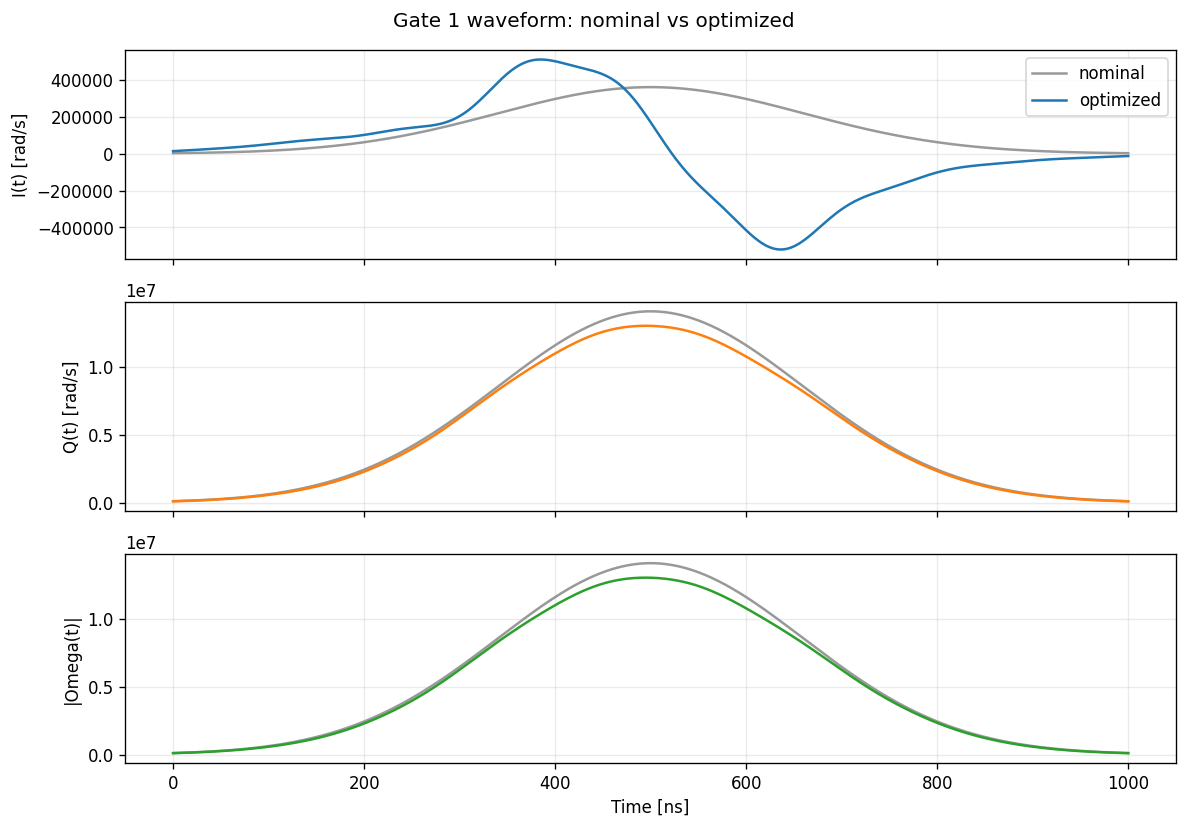

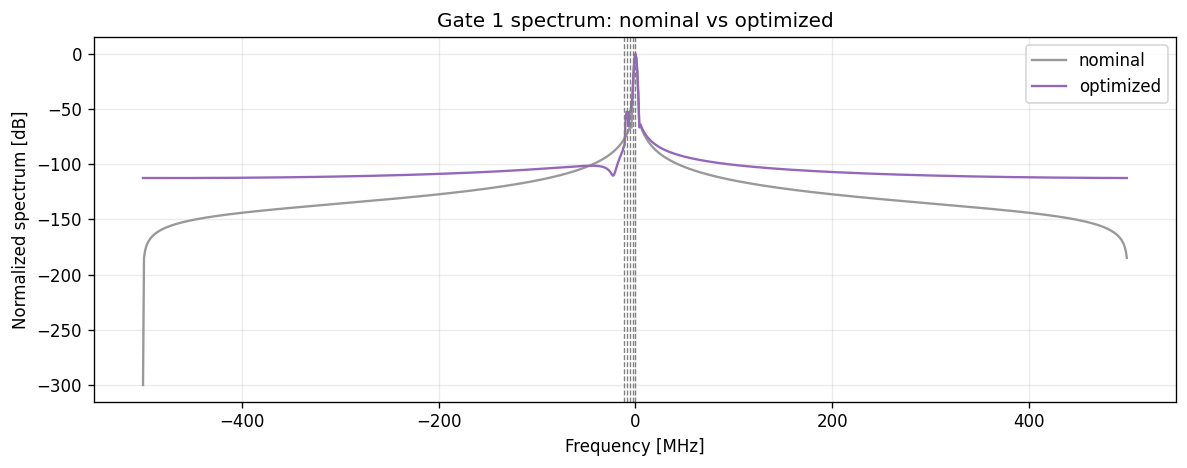

,n,amp_rad_s_nominal,amp_Mrad_s_nominal,phase_rad_nominal,omega_hz_nominal,omega_MHz_nominal,amp_rad_s_optimized,amp_Mrad_s_optimized,phase_rad_optimized,omega_hz_optimized,omega_MHz_optimized
0,0,1.408086e+07,14.080865,1.545128,0.0,0.000,1.329547e+07,13.295467,1.461501,3.395059e+04,0.033951
1,1,0.000000e+00,0.000000,0.000000,-2840000.0,-2.840,3.220796e+05,0.322080,0.021076,-2.363873e+06,-2.363873
2,2,0.000000e+00,0.000000,0.000000,-5722000.0,-5.722,4.146082e+04,0.041461,0.381586,-5.582739e+06,-5.582739
3,3,0.000000e+00,0.000000,0.000000,-8646000.0,-8.646,3.801042e+04,0.038010,0.231576,-8.566833e+06,-8.566833
4,4,0.000000e+00,0.000000,0.000000,-11612000.0,-11.612,0.000000e+00,0.000000,0.000000,-1.161200e+07,-11.612000


### Gate 2: `SQR_bc8194a85a260be4c0959c6c4d8d7ae1`

Nominal fidelity at T=650 ns: 0.928767 | Optimized fidelity: 0.951451


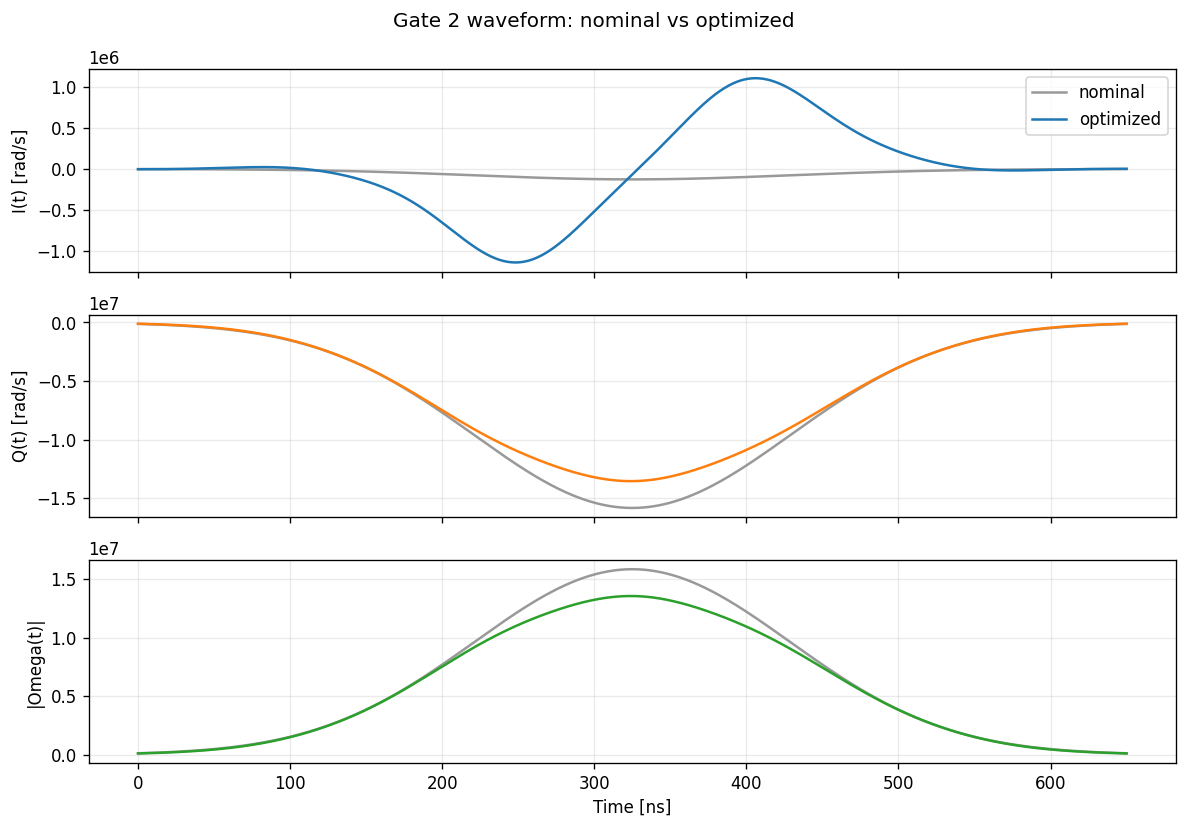

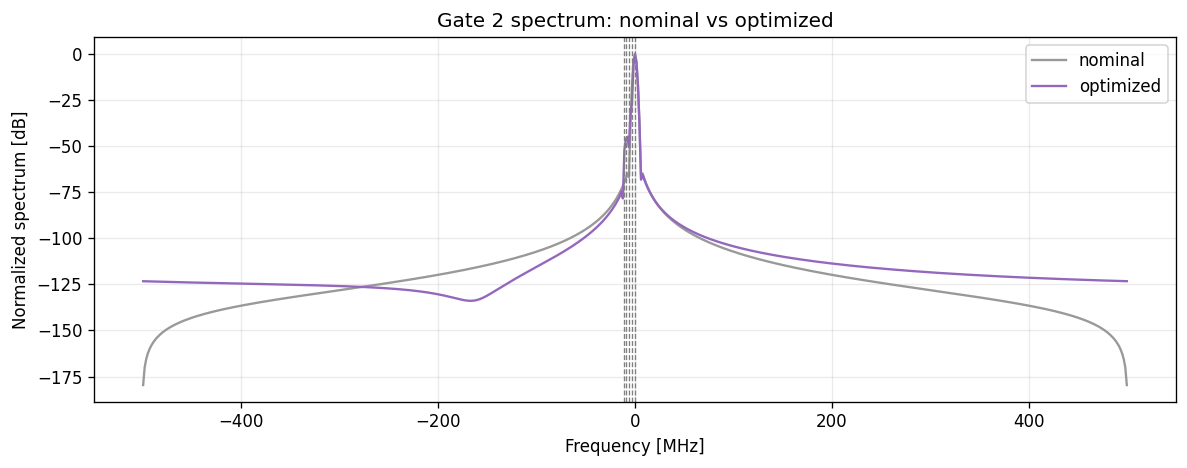

,n,amp_rad_s_nominal,amp_Mrad_s_nominal,phase_rad_nominal,omega_hz_nominal,omega_MHz_nominal,amp_rad_s_optimized,amp_Mrad_s_optimized,phase_rad_optimized,omega_hz_optimized,omega_MHz_optimized
0,0,-1.583769e+07,-15.837689,1.562768,0.0,0.000,-1.462938e+07,-14.629384,1.499437,3.543981e+04,0.035440
1,1,0.000000e+00,0.000000,0.000000,-2840000.0,-2.840,1.208305e+06,1.208305,0.935980,-2.726011e+06,-2.726011
2,2,0.000000e+00,0.000000,0.000000,-5722000.0,-5.722,-4.133478e+04,-0.041335,1.413129,-5.884764e+06,-5.884764
3,3,0.000000e+00,0.000000,0.000000,-8646000.0,-8.646,-8.416798e+04,-0.084168,0.430668,-8.675038e+06,-8.675038
4,4,0.000000e+00,0.000000,0.000000,-11612000.0,-11.612,0.000000e+00,0.000000,0.000000,-1.161200e+07,-11.612000


### Gate 3: `SQR_789278ba62949511b06e9d76a4bb8437`

Nominal fidelity at T=750 ns: 0.921908 | Optimized fidelity: 0.941427


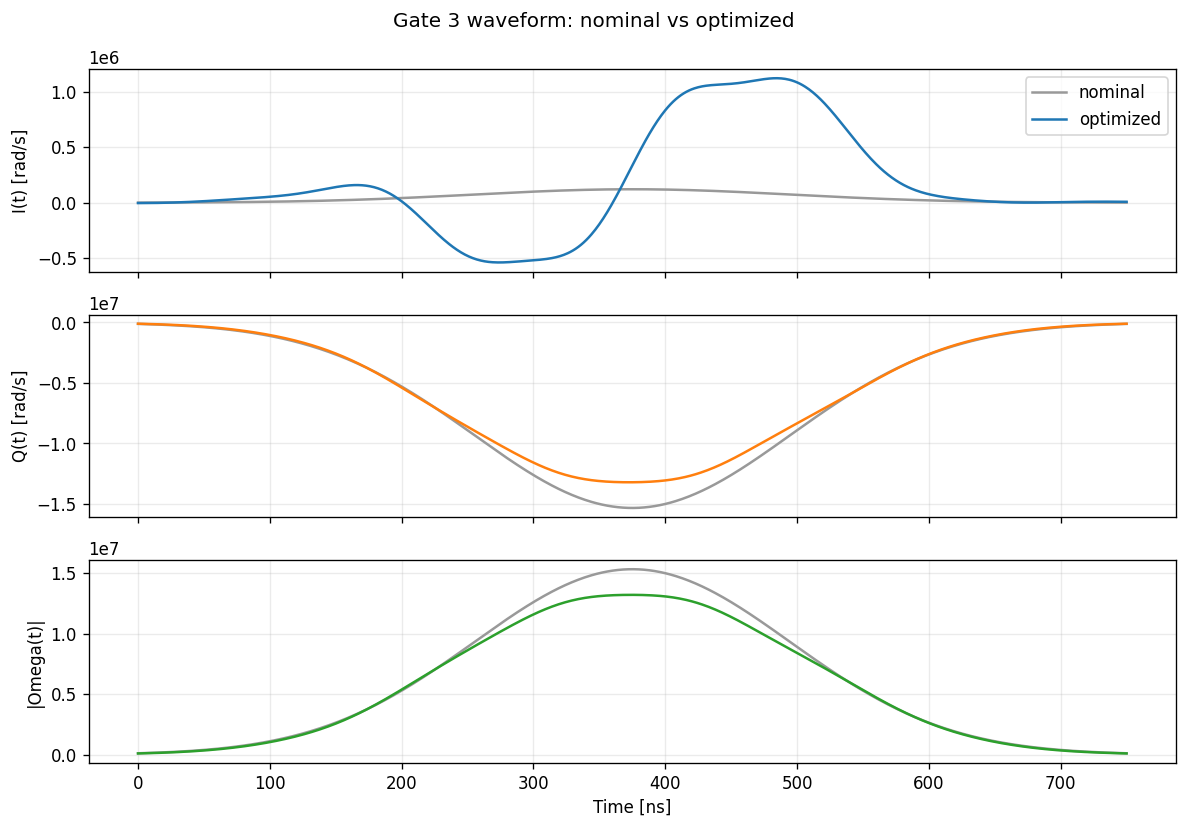

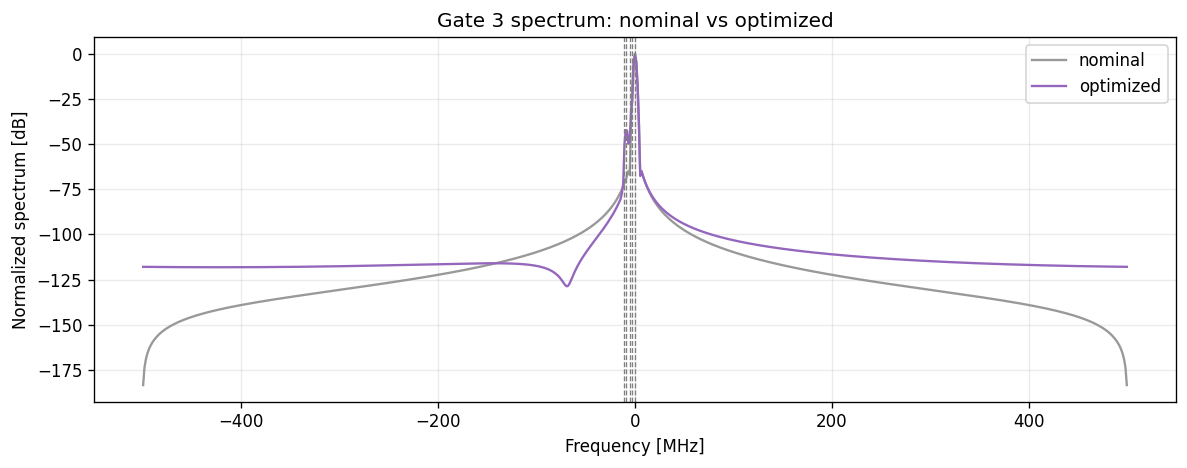

,n,amp_rad_s_nominal,amp_Mrad_s_nominal,phase_rad_nominal,omega_hz_nominal,omega_MHz_nominal,amp_rad_s_optimized,amp_Mrad_s_optimized,phase_rad_optimized,omega_hz_optimized,omega_MHz_optimized
0,0,-1.533235e+07,-15.332348,1.578716,0.0,0.000,-1.428515e+07,-14.285150,1.545904,2.420919e+04,0.024209
1,1,0.000000e+00,0.000000,0.000000,-2840000.0,-2.840,-1.047198e+06,-1.047198,-1.529284,-2.605817e+06,-2.605817
2,2,0.000000e+00,0.000000,0.000000,-5722000.0,-5.722,1.202209e+05,0.120221,-0.602846,-5.488528e+06,-5.488528
3,3,0.000000e+00,0.000000,0.000000,-8646000.0,-8.646,-1.393588e+05,-0.139359,-0.029997,-8.655920e+06,-8.655920
4,4,0.000000e+00,0.000000,0.000000,-11612000.0,-11.612,0.000000e+00,0.000000,0.000000,-1.161200e+07,-11.612000


In [ ]:
for result in gate_results:
    display(Markdown(f"### Gate {result['gate_index']}: `{result['gate'].name}`"))
    print(
        f"Nominal fidelity at T={result['selected_duration_ns']} ns: {result['nominal']['subspace_fidelity']:.6f} | "
        f"Optimized fidelity: {result['selected_point']['subspace_fidelity']:.6f}"
    )
    plot_waveform_overlay(
        result["nominal"]["waveform"],
        result["selected_point"]["waveform"],
        title=f"Gate {result['gate_index']} waveform: nominal vs optimized",
    )
    plot_spectrum_overlay(
        result["nominal"]["waveform"],
        result["selected_point"]["waveform"],
        title=f"Gate {result['gate_index']} spectrum: nominal vs optimized",
    )
    display(tone_comparison_table(result["nominal"]["waveform"], result["selected_point"]["waveform"]))

## Selected Optimization History

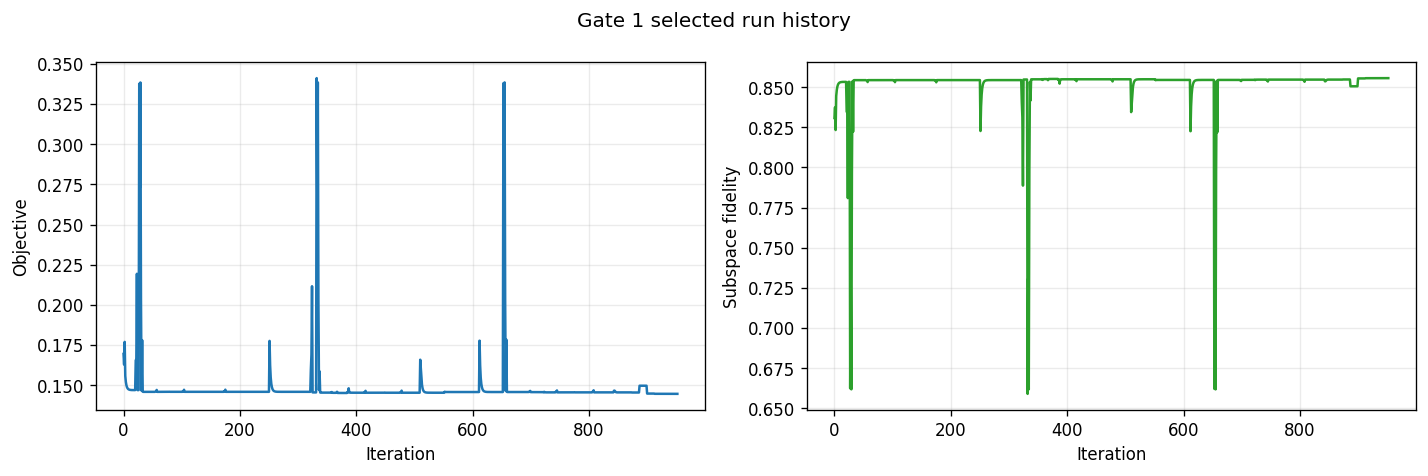

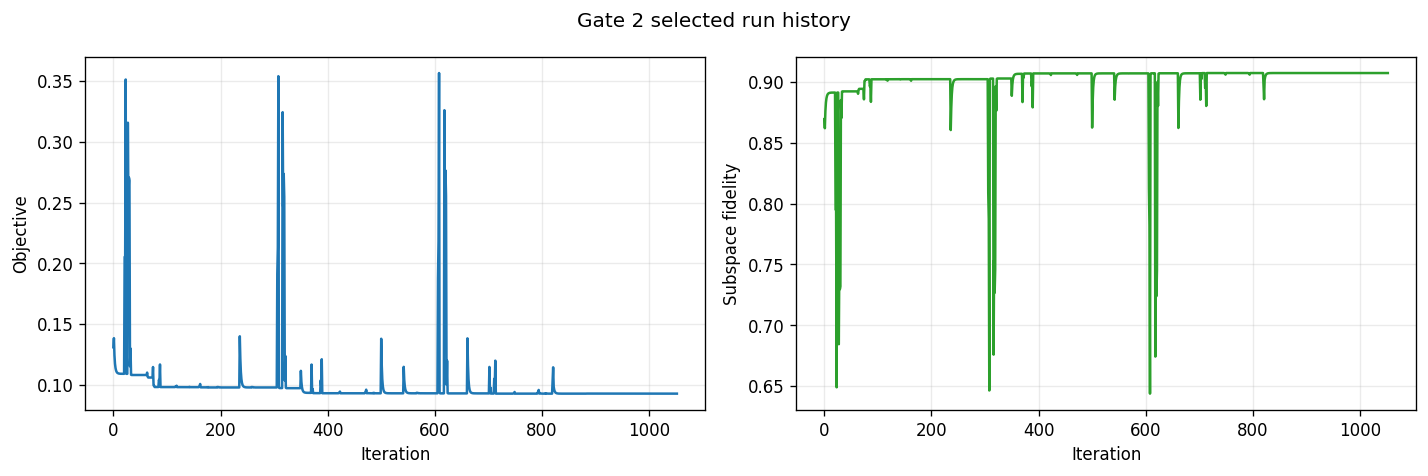

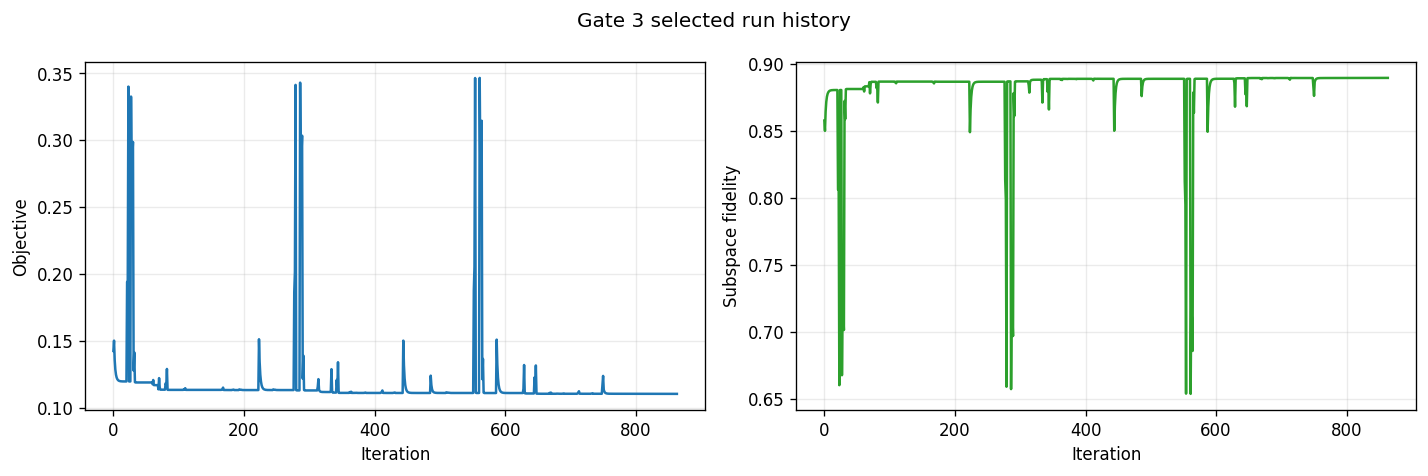

In [ ]:
for result in gate_results:
    plot_selected_history(
        result["selected_point"],
        title=f"Gate {result['gate_index']} selected run history",
    )

In [ ]:
report_lines = [
    "# Three-Gate SQR Optimization Audit",
    "",
    "## Original Execution Path",
    "- Notebook entrypoints: `cqed_sim.analysis.run_speedlimit_sweep_point` and `cqed_sim.analysis.evaluate_nominal_case`.",
    "- Pre-refactor optimization internals: `cqed_sim.calibration.sqr` used a custom reduced two-level QuTiP propagation path per manifold.",
    "",
    "## Current Shared-Stack Path",
    "- Waveform generation: `cqed_sim.pulses.calibration.build_sqr_tone_specs`.",
    "- Hamiltonian construction: `cqed_sim.sim.runner.hamiltonian_time_slices`.",
    "- Propagation: coherent runs use `qutip.propagator`; dissipative runs use `qutip.mesolve` with the shared collapse-operator convention.",
    "- Objective: `cqed_sim.calibration.evaluate_guarded_sqr_target` computes logical process fidelity and guard selectivity.",
    "",
    "## Convention Audit Findings",
    "- Tensor ordering is qubit-major (`|q> ⊗ |n>`), matching the main `cqed_sim` convention.",
    "- Tone and phase conventions now come from the shared pulse builders instead of notebook-local reduced-model logic.",
    "- The main mismatch found in the original path was architectural: the notebook already imported `cqed_sim.analysis`, but that path still delegated to duplicated reduced-model Hamiltonian/propagation logic inside `cqed_sim.calibration.sqr`.",
    "",
    "## Validation Summary",
    f"- Dissipation enabled in this run: {any(value not in (None, 0, 0.0) for value in (study.qb_t1_relax_ns, study.qb_t2_ramsey_ns, study.qb_t2_echo_ns, study.cavity_kappa_1_per_s))}.",
    f"- Parallel candidate evaluation enabled in this run: {study.parallel_enabled} (n_jobs={study.parallel_n_jobs}).",
    f"- Representative simulation mode reported by the selected points: {', '.join(sorted({str(result['selected_point'].get('simulation_mode', 'unitary')) for result in gate_results}))}.",
    f"- Summary artifact: `{summary_path}`.",
    "",
    "## Recommended Follow-Up",
    "1. Increase `MULTISTART` and optimizer iteration caps once the shared-stack path is validated at the desired physical parameters.",
    "2. Enable `QB_T1_RELAX_NS` and `QB_T2_RAMSEY_NS` or `QB_T2_ECHO_NS` for open-system optimization studies.",
    "3. Use `PARALLEL_ENABLED = True` only when running independent candidate starts on a machine with enough CPU and RAM to support spawned workers.",
]
report_text = "\n".join(report_lines)
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
REPORT_PATH.write_text(report_text, encoding="utf-8")
display(Markdown(report_text))
print("Wrote report:", REPORT_PATH)

## Concise Audit Report

## Notes

- `selected_duration_ns` is the duration used for the waveform overlay.
- If a gate does not cross the chosen fidelity threshold on the scanned grid, the notebook falls back to the best scanned duration for that gate.
- The gray waveform is the nominal multitone Gaussian pulse with no optimized corrections.
- The colored waveform includes the optimized amplitude, phase, and detuning corrections returned by the guarded SQR calibration.
- Setting `QB_T1_RELAX_NS` and a corresponding `QB_T2_*` value switches the evaluation path to a dissipative channel metric using the shared Lindblad solver path.
- Setting `PARALLEL_ENABLED = True` parallelizes independent multistart candidates at each sweep point; serial execution is used automatically when live reporting is requested.